<a href="https://colab.research.google.com/github/winarwahyuw/data-science-250401020025-winar-wahyu-wulansari/blob/main/Data_Science_Pertemuan_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## PERTEMUAN 13
#### Nama : Winar Wahyu Wulansari
#### NIM : 250401020025
#### Kelas : IF405


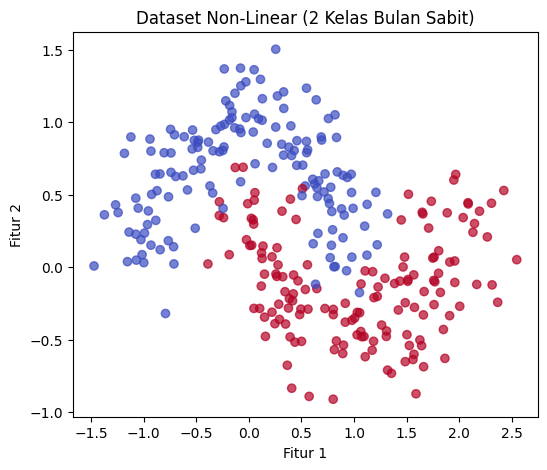

In [1]:

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Membuat dataset non-linear
X, y = make_moons(
    n_samples=300,
    noise=0.2,
    random_state=42
)

# Visualisasi dataset
plt.figure(figsize=(6, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="coolwarm",
    alpha=0.7
)

plt.title("Dataset Non-Linear (2 Kelas Bulan Sabit)")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")

plt.show()

In [3]:
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Membagi data menjadi data latih dan data uji
X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Membangun arsitektur
model = Sequential([
    Dense(16, activation="relu", input_shape=(2,)),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Mengompilasi model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Menampilkan ringkasan
model.summary()

# Melatih model
history = model.fit(
    X_tr,
    y_tr,
    epochs=30,
    validation_split=0.2,
    verbose=0
)

print("Pelatihan model selesai.")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Pelatihan model selesai.


Loss pada data uji     : 0.318
Akurasi pada data uji : 0.900


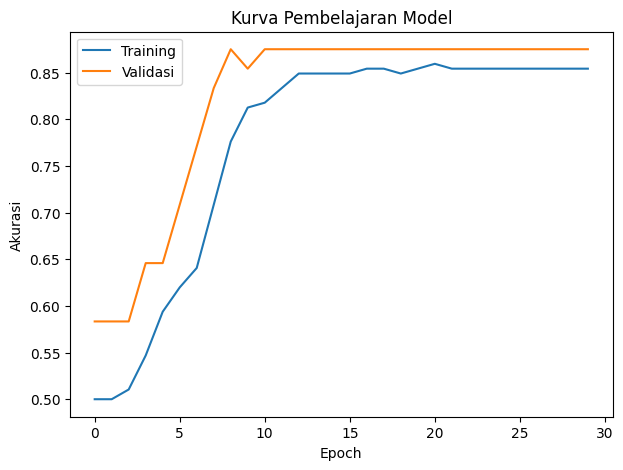

In [4]:
import matplotlib.pyplot as plt

# Evaluasi model pada data uji
loss, acc = model.evaluate(X_te, y_te, verbose=0)

print(f"Loss pada data uji     : {loss:.3f}")
print(f"Akurasi pada data uji : {acc:.3f}")

# Visualisasi kurva pembelajaran
plt.figure(figsize=(7, 5))

plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validasi")

plt.xlabel("Epoch")
plt.ylabel("Akurasi")
plt.title("Kurva Pembelajaran Model")
plt.legend()

plt.show()


In [5]:
# Dataset ulasan produk
ulasan = [
    "Barangnya bagus banget, pengiriman cepat",
    "Kualitas jelek, tidak sesuai deskripsi",
    "Sangat puas, akan beli lagi",
    "Kecewa, barang rusak saat sampai",
    "Recommended, harga sesuai kualitas",
    "Buruk sekali, tidak sesuai ekspektasi",
    "Produknya berkualitas dan sangat memuaskan",
    "Pengiriman lama dan pelayanan buruk",
    "Barang sesuai gambar, puas sekali",
    "Tidak akan beli lagi, mengecewakan",
    "Kemasan rapi dan produk bagus",
    "Barang cacat dan kualitas rendah",
    "Pelayanan ramah dan pengiriman cepat",
    "Produk tidak berfungsi dengan baik",
    "Harga murah, kualitas mantap",
    "Sangat kecewa dengan produk ini",
    "Kualitas sangat baik, sesuai harapan",
    "Barang datang terlambat dan rusak",
    "Penjual responsif dan terpercaya",
    "Produk palsu, sangat mengecewakan",
    "Pengalaman belanja sangat memuaskan",
    "Barang tidak sesuai pesanan",
    "Produk bagus dan mudah digunakan",
    "Kualitas buruk, tidak layak dibeli",
    "Sangat direkomendasikan untuk dibeli",
    "Kecewa dengan pelayanan penjual",
    "Harga sebanding dengan kualitas",
    "Produk cepat rusak setelah dipakai",
    "Barang original dan berkualitas",
    "Tidak puas dengan hasilnya",
    "Pengiriman sangat cepat",
    "Barang tidak sesuai foto",
    "Produk sangat membantu kebutuhan saya",
    "Kualitas mengecewakan",
    "Pelayanan memuaskan dan ramah",
    "Barang rusak saat diterima",
    "Sangat puas dengan pembelian ini",
    "Produk tidak sesuai deskripsi",
    "Kualitas luar biasa, sangat bagus",
    "Pengalaman belanja sangat buruk"
]

# Label sentimen
label = [
    1, 0, 1, 0, 1, 0,
    1, 0, 1, 0,
    1, 0, 1, 0, 1, 0,
    1, 0, 1, 0,
    1, 0, 1, 0, 1, 0,
    1, 0, 1, 0,
    1, 0, 1, 0, 1, 0,
    1, 0, 1, 0
]

print("Jumlah ulasan:", len(ulasan))
print("Jumlah label :", len(label))


Jumlah ulasan: 40
Jumlah label : 40


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Mengubah teks menjadi representasi TF-IDF
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

# Menampilkan informasi hasil TF-IDF
print("Jumlah kata unik:", len(tfidf.get_feature_names_out()))
print("10 kata pertama:")
print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 74
10 kata pertama:
['akan' 'bagus' 'baik' 'banget' 'barang' 'barangnya' 'belanja' 'beli'
 'berfungsi' 'berkualitas']


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Membagi data menjadi data latih dan data uji
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text,
    label,
    test_size=0.2,
    random_state=42
)

# Melatih model Logistic Regression
model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

# Menghitung akurasi model
akurasi = model_sentimen.score(Xt_te, yt_te)
print(f"Akurasi model sentimen: {akurasi:.3f}")

# Menguji model dengan kalimat baru
kalimat_baru = ["Pelayanan sangat memuaskan dan ramah"]
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))

print("Hasil prediksi:", "Positif" if pred[0] == 1 else "Negatif")

Akurasi model sentimen: 0.250
Hasil prediksi: Positif


## Kesimpulan

### Apa yang Dipelajari
- Mempelajari penggunaan **Neural Network** untuk klasifikasi dataset non-linear menggunakan TensorFlow/Keras.
- Mempelajari **TF-IDF** untuk mengubah data teks menjadi fitur numerik.
- Mempelajari **Logistic Regression** untuk klasifikasi sentimen ulasan produk.

### Insight
- Neural Network dapat digunakan untuk menangani data dengan pola non-linear seperti dataset bulan sabit.
- TF-IDF berhasil menghasilkan **74 kata unik** dari 40 ulasan.
- Model sentimen menghasilkan akurasi **0,25 (25%)**, sehingga performanya masih rendah meskipun prediksi kalimat baru menghasilkan sentimen positif.

### Batasan
- Dataset sentimen hanya terdiri dari **40 ulasan**, sehingga terlalu kecil untuk menghasilkan model yang optimal.
- Data memiliki pola label yang sederhana dan kemungkinan kurang merepresentasikan variasi sentimen nyata.
- Akurasi **25%** menunjukkan bahwa model Logistic Regression masih perlu diperbaiki, misalnya dengan menambah data, melakukan preprocessing teks, dan menggunakan metode klasifikasi atau parameter yang lebih sesuai.